# Horse Scoring & Bloodline Analytics — Python Analysis

**Dataset:** 40 Arabian horses · 3 judges · 6 AHA-style halter categories (0–20 each, 120 max per judge) · 15 parent records (5 sires, 10 dam sires).

> The dataset is **synthetic practice data** (only the sire names are real). Findings describe this dataset, not real bloodlines.

**Questions this notebook answers**
1. Which sire lines produce the highest-scoring offspring, and is the gap statistically meaningful?
2. Do parent show scores predict offspring scores?
3. How do scores differ by age group and sex?
4. What are each bloodline's conformation strengths and weaknesses?
5. Are the judges consistent with each other?

Every table and chart here is also written to `../tables/` and `../charts/`; `../powerbi/` gets the star-schema CSVs that feed the Power BI model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy import stats

BASE = Path.cwd().parent if Path.cwd().name == 'python' else Path.cwd()
SRC = BASE / 'data' / 'arabian_horse_score_dataset.xlsx'
CHARTS, TABLES, PBI = BASE / 'charts', BASE / 'tables', BASE / 'powerbi' / 'data'
for d in (CHARTS, TABLES, PBI):
    d.mkdir(parents=True, exist_ok=True)

SHOW_YEAR = 2026          # reference year for computing age
TRAITS = ['Type', 'Head_Neck', 'Body_Topline', 'Legs', 'Movement', 'Balance']
TRAIT_LABELS = {t: t.replace('_', ' / ' if t in ('Head_Neck', 'Body_Topline') else ' ') for t in TRAITS}
TIERS = [(112, 'Elite'), (106, 'High'), (100, 'Developing'), (-np.inf, 'Needs Review')]

pd.set_option('display.precision', 2)
pd.set_option('display.width', 140)

## 1 · Chart style
One consistent look: single-hue bars for magnitude, blue↔red diverging maps for above/below average, and fixed colors per sire.

In [2]:
BLUE, RED, INK, INK2, MUTED, GRID, SURFACE = '#2a78d6', '#e34948', '#0b0b0b', '#52514e', '#8a8984', '#e6e5e1', '#fcfcfb'
SIRE_COLORS = {  # fixed categorical order — colour follows the sire, never its rank
    'Abha Qatar': '#2a78d6', 'Cavali by Da Valentio': '#eb6834', 'Pogrom': '#1baf7a',
    'Titan AS': '#eda100', 'Van Gogh AM': '#e87ba4'}
SEQ = LinearSegmentedColormap.from_list('seq', ['#cde2fb', '#86b6ef', '#2a78d6', '#184f95', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div', ['#e34948', '#f3b3b1', '#f0efec', '#9ec5f4', '#256abf'])

mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.facecolor': SURFACE,
    'figure.facecolor': SURFACE, 'xtick.color': INK2, 'ytick.color': INK2, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'savefig.dpi': 160, 'savefig.bbox': 'tight', 'legend.frameon': False})

def subtitle(ax, text):
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK2, fontsize=9.5, va='bottom')

def save(fig, name):
    fig.savefig(CHARTS / f'{name}.png')
    plt.show()

## 2 · Load and validate the data

In [3]:
profile = pd.read_excel(SRC, sheet_name='Horse_Profile')
scores  = pd.read_excel(SRC, sheet_name='Judge_Scores')
parents = pd.read_excel(SRC, sheet_name='Parent_Reference')

# TotalScore is an Excel formula in the source, so recompute it from the six traits
scores['TotalScore'] = scores[TRAITS].sum(axis=1).round(2)
profile['Age'] = SHOW_YEAR - profile['BirthYear']

print(f'{len(profile)} horses | {len(scores)} judge score rows | {len(parents)} parent records')
print('Missing values:', int(profile.isna().sum().sum() + scores.isna().sum().sum()))
print('Duplicate HorseIDs:', profile.HorseID.duplicated().sum())
print('Scores per horse:', scores.groupby('HorseID').size().unique())
print('Trait scores within 0-20:', bool(scores[TRAITS].ge(0).all().all() and scores[TRAITS].le(20).all().all()))
print('Every score row matches a horse:', scores.HorseID.isin(profile.HorseID).all())
print('Every sire / dam sire has a parent record:',
      profile.Sire.isin(parents.ParentName).all(), profile.DamSire.isin(parents.ParentName).all())

40 horses | 120 judge score rows | 15 parent records
Missing values: 0
Duplicate HorseIDs: 0
Scores per horse: [3]
Trait scores within 0-20: True
Every score row matches a horse: True
Every sire / dam sire has a parent record: True True


### Data-quality flags
Halter sex classes are age-based: **colt/filly** are under 4, **stallion/mare** 4+. The check below flags rows where the sex label and birth year disagree. They're kept in the analysis but are listed so they can be fixed at source.

In [4]:
def sex_age_flag(r):
    if r.Sex in ('Colt', 'Filly') and r.Age >= 4: return f'{r.Sex} but {r.Age} yrs old (expected under 4)'
    if r.Sex in ('Stallion', 'Mare') and r.Age < 4: return f'{r.Sex} but {r.Age} yrs old (expected 4+)'
    return None

profile['DataFlag'] = profile.apply(sex_age_flag, axis=1)
flags = profile.loc[profile.DataFlag.notna(), ['HorseID', 'RegisteredName', 'Sex', 'BirthYear', 'AgeGroup', 'DataFlag']]
print(f'{len(flags)} of {len(profile)} horses have a sex/age mismatch (reference year {SHOW_YEAR})')
print('Age range by AgeGroup:'); print(profile.groupby('AgeGroup').Age.agg(['min', 'max']))
flags.to_csv(TABLES / 'data_quality_flags.csv', index=False)
flags

17 of 40 horses have a sex/age mismatch (reference year 2026)
Age range by AgeGroup:
             min  max
AgeGroup             
Junior         2    2
Mature         5    6
Young Horse    3    4


,HorseID,RegisteredName,Sex,BirthYear,AgeGroup,DataFlag
2,HA-003,HA Nadir Sundance,Stallion,2024,Junior,Stallion but 2 yrs old (expected 4+)
3,HA-004,HA Layla Dream,Mare,2023,Young Horse,Mare but 3 yrs old (expected 4+)
4,HA-005,HA Zafir Golden Star,Stallion,2023,Young Horse,Stallion but 3 yrs old (expected 4+)
7,HA-008,HA Noor Mirage,Mare,2024,Junior,Mare but 2 yrs old (expected 4+)
9,HA-010,HA Sahara Desert Rose,Mare,2024,Junior,Mare but 2 yrs old (expected 4+)
12,HA-013,HA Jasmine Sundance,Mare,2024,Junior,Mare but 2 yrs old (expected 4+)
16,HA-017,HA Noura Al Jannat,Colt,2022,Young Horse,Colt but 4 yrs old (expected under 4)
18,HA-019,HA Saffron Golden Star,Filly,2020,Mature,Filly but 6 yrs old (expected under 4)
20,HA-021,HA Majid Al Jannat,Filly,2020,Mature,Filly but 6 yrs old (expected under 4)
22,HA-023,HA Rashid Golden Star,Colt,2020,Mature,Colt but 6 yrs old (expected under 4)


## 3 · Build the horse-level summary
Average of the three judges per trait, plus judge spread (how much the judges disagree) and each horse's computed strongest/weakest trait.

In [5]:
def tier(x):
    return next(label for cut, label in TIERS if x >= cut)

hs = (scores.groupby('HorseID')[TRAITS + ['TotalScore']].mean()
      .rename(columns={'TotalScore': 'AvgTotal'}))
hs['JudgeSpread'] = scores.groupby('HorseID').TotalScore.agg(lambda s: s.max() - s.min())
hs['MainStrength'] = hs[TRAITS].idxmax(axis=1)
hs['FocusArea'] = hs[TRAITS].idxmin(axis=1)
hs = profile.set_index('HorseID').join(hs).reset_index()
hs['Rank'] = hs.AvgTotal.rank(ascending=False, method='min').astype(int)
hs['ScoreTier'] = hs.AvgTotal.apply(tier)

pscore = parents.set_index('ParentName').HypotheticalShowScore
hs['SireScore'] = hs.Sire.map(pscore)
hs['DamSireScore'] = hs.DamSire.map(pscore)
hs['MidParentScore'] = hs[['SireScore', 'DamSireScore']].mean(axis=1)

hs = hs.sort_values('Rank')
hs.to_csv(TABLES / 'horse_summary.csv', index=False)
hs[['Rank', 'RegisteredName', 'Sire', 'Sex', 'AgeGroup', 'AvgTotal', 'ScoreTier', 'MainStrength', 'FocusArea']].head(10)

,Rank,RegisteredName,Sire,Sex,AgeGroup,AvgTotal,ScoreTier,MainStrength,FocusArea
33,1,HA Rami Royal Flame,Pogrom,Stallion,Mature,114.33,Elite,Type,Legs
39,2,HA Kairo Marquis,Pogrom,Filly,Young Horse,113.93,Elite,Movement,Head_Neck
8,3,HA Rayan Dream,Pogrom,Colt,Junior,113.87,Elite,Movement,Legs
0,4,HA Amira Legacy,Pogrom,Gelding,Young Horse,113.43,Elite,Balance,Legs
28,5,HA Rahma Al Jannat,Pogrom,Gelding,Mature,112.93,Elite,Movement,Head_Neck
22,6,HA Rashid Golden Star,Cavali by Da Valentio,Colt,Mature,112.80,Elite,Head_Neck,Legs
30,7,HA Mira Valentino,Cavali by Da Valentio,Colt,Mature,112.73,Elite,Type,Movement
16,8,HA Noura Al Jannat,Cavali by Da Valentio,Colt,Young Horse,112.47,Elite,Type,Head_Neck
3,9,HA Layla Dream,Cavali by Da Valentio,Mare,Young Horse,112.13,Elite,Movement,Body_Topline
27,9,HA Nashira Royal Flame,Cavali by Da Valentio,Colt,Mature,112.13,Elite,Type,Body_Topline


In [6]:
k = {
    'Horses': len(hs),
    'Average total (of 120)': hs.AvgTotal.mean(),
    'Median total': hs.AvgTotal.median(),
    'Top horse': f"{hs.iloc[0].RegisteredName} ({hs.iloc[0].AvgTotal:.1f})",
    'Elite horses (>=112)': int((hs.ScoreTier == 'Elite').sum()),
    'Avg judge spread (pts)': hs.JudgeSpread.mean(),
}
pd.Series(k, name='KPI').to_frame()

,KPI
Horses,40
Average total (of 120),109.84
Median total,110.42
Top horse,HA Rami Royal Flame (114.3)
Elite horses (>=112),11
Avg judge spread (pts),4.51


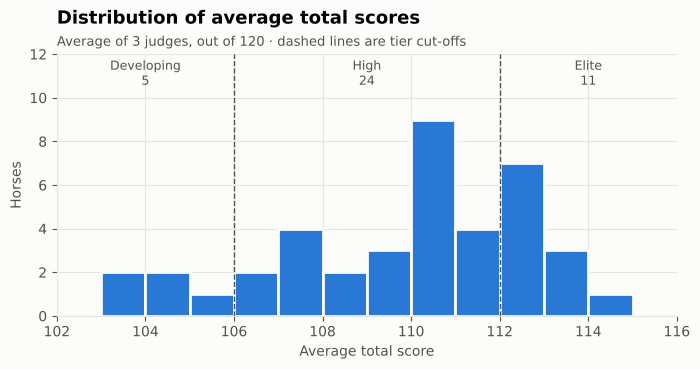

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))
order = ['Needs Review', 'Developing', 'High', 'Elite']
counts = hs.ScoreTier.value_counts().reindex(order, fill_value=0)
ax.hist(hs.AvgTotal, bins=np.arange(102, 116, 1), color=BLUE, edgecolor=SURFACE, linewidth=2)
ax.set_ylim(0, 12); ax.set_xlim(102, 116)
for cut in (106, 112):
    ax.axvline(cut, color=INK2, lw=1, ls='--')
ax.text(104, 10.6, f'Developing\n{counts["Developing"]}', ha='center', color=INK2, fontsize=9)
ax.text(109, 10.6, f'High\n{counts["High"]}', ha='center', color=INK2, fontsize=9)
ax.text(114, 10.6, f'Elite\n{counts["Elite"]}', ha='center', color=INK2, fontsize=9)
ax.set_title('Distribution of average total scores', pad=22)
subtitle(ax, 'Average of 3 judges, out of 120 · dashed lines are tier cut-offs')
ax.set_xlabel('Average total score'); ax.set_ylabel('Horses')
save(fig, '01_score_distribution')

## 4 · Bloodline (sire line) comparison

In [8]:
sire = (hs.groupby('Sire').agg(Bloodline=('PaternalLine', 'first'), Horses=('HorseID', 'count'),
                              AvgTotal=('AvgTotal', 'mean'), StdDev=('AvgTotal', 'std'),
                              Min=('AvgTotal', 'min'), Max=('AvgTotal', 'max'),
                              EliteShare=('ScoreTier', lambda s: (s == 'Elite').mean()),
                              SireShowScore=('SireScore', 'first'))
        .sort_values('AvgTotal', ascending=False))
sire['TopHorse'] = hs.loc[hs.groupby('Sire').AvgTotal.idxmax()].set_index('Sire').RegisteredName
sire['GapVsSire'] = sire.AvgTotal - sire.SireShowScore
sire.to_csv(TABLES / 'sire_comparison.csv')
sire

,Bloodline,Horses,AvgTotal,StdDev,Min,Max,EliteShare,SireShowScore,TopHorse,GapVsSire
Sire,,,,,,,,,,
Pogrom,Polish/International,10,112.31,1.57,110.37,114.33,0.50,112.7,HA Rami Royal Flame,-0.39
Cavali by Da Valentio,Valentino/International,7,112.15,0.69,110.73,112.80,0.86,112.8,HA Rashid Golden Star,-0.65
Abha Qatar,Qatari/Spanish,8,108.95,2.02,105.80,111.10,0.00,112.9,HA Saffron Golden Star,-3.95
Van Gogh AM,Brazilian/International,8,108.90,1.59,106.83,111.43,0.00,111.7,HA Malika Amethyst,-2.80
Titan AS,American/International,7,106.10,2.76,103.47,110.17,0.00,111.3,HA Soraya Amethyst,-5.20


In [9]:
groups = [g.AvgTotal.values for _, g in hs.groupby('Sire')]
f, p_anova = stats.f_oneway(*groups)
h, p_kw = stats.kruskal(*groups)
ss_between = sum(len(g) * (g.mean() - hs.AvgTotal.mean())**2 for g in groups)
eta2 = ss_between / ((hs.AvgTotal - hs.AvgTotal.mean())**2).sum()
print(f'One-way ANOVA: F = {f:.2f}, p = {p_anova:.2g}')
print(f'Kruskal-Wallis (non-parametric check): H = {h:.2f}, p = {p_kw:.2g}')
print(f'Eta-squared: {eta2:.2f} -> sire line explains {eta2:.0%} of the variation in horse scores')

# Pairwise Welch t-tests with Bonferroni correction
rows, names = [], sire.index.tolist()
for i, a in enumerate(names):
    for b in names[i+1:]:
        t, p = stats.ttest_ind(hs.loc[hs.Sire == a, 'AvgTotal'], hs.loc[hs.Sire == b, 'AvgTotal'], equal_var=False)
        rows.append({'SireA': a, 'SireB': b, 'MeanDiff': sire.AvgTotal[a] - sire.AvgTotal[b],
                     'p_raw': p, 'p_bonferroni': min(p * 10, 1)})
pairwise = pd.DataFrame(rows).sort_values('p_raw')
pairwise['Significant (0.05)'] = pairwise.p_bonferroni < 0.05
pairwise.to_csv(TABLES / 'sire_pairwise_tests.csv', index=False)
pairwise

One-way ANOVA: F = 15.61, p = 2e-07
Kruskal-Wallis (non-parametric check): H = 26.17, p = 2.9e-05
Eta-squared: 0.64 -> sire line explains 64% of the variation in horse scores


,SireA,SireB,MeanDiff,p_raw,p_bonferroni,Significant (0.05)
2,Pogrom,Van Gogh AM,3.40,3.89e-04,3.89e-03,True
5,Cavali by Da Valentio,Van Gogh AM,3.24,4.08e-04,4.08e-03,True
3,Pogrom,Titan AS,6.20,5.08e-04,5.08e-03,True
6,Cavali by Da Valentio,Titan AS,6.04,9.16e-04,9.16e-03,True
1,Pogrom,Abha Qatar,3.35,2.00e-03,2.00e-02,True
4,Cavali by Da Valentio,Abha Qatar,3.19,2.44e-03,2.44e-02,True
9,Van Gogh AM,Titan AS,2.80,4.18e-02,4.18e-01,False
8,Abha Qatar,Titan AS,2.85,4.61e-02,4.61e-01,False
0,Pogrom,Cavali by Da Valentio,0.16,7.81e-01,1.00e+00,False
7,Abha Qatar,Van Gogh AM,0.05,9.57e-01,1.00e+00,False


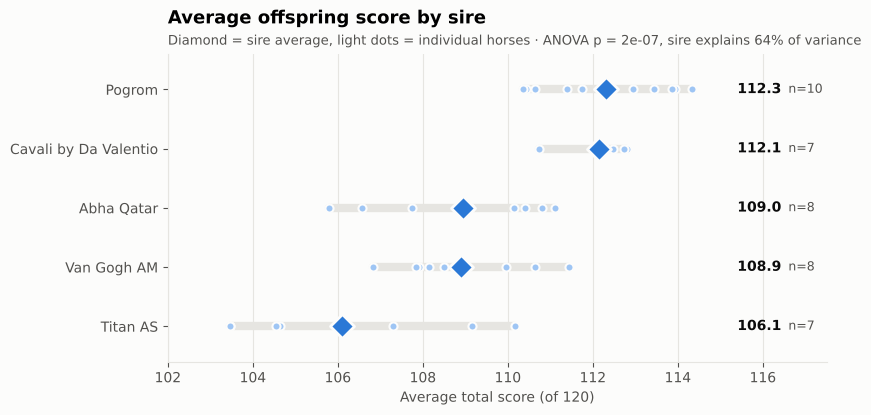

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4))
order = sire.index[::-1]
for i, s in enumerate(order):
    pts = hs.loc[hs.Sire == s, 'AvgTotal']
    ax.hlines(i, pts.min(), pts.max(), color=GRID, lw=6, capstyle='round', zorder=1)
    ax.scatter(pts, np.full(len(pts), i), s=34, color='#9ec5f4', edgecolor=SURFACE, linewidth=1.5, zorder=2)
    ax.scatter(sire.loc[s, 'AvgTotal'], i, s=150, marker='D', color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.text(115.4, i, f"{sire.loc[s, 'AvgTotal']:.1f}", va='center', color=INK, fontsize=10, fontweight='bold')
    ax.text(116.6, i, f"n={sire.loc[s, 'Horses']}", va='center', color=INK2, fontsize=9)
ax.set_yticks(range(len(order)), order)
ax.set_xlim(102, 117.5); ax.set_ylim(-0.6, len(order) - 0.4); ax.grid(axis='y', visible=False)
ax.set_title('Average offspring score by sire', pad=22)
subtitle(ax, f'Diamond = sire average, light dots = individual horses · ANOVA p = {p_anova:.1g}, sire explains {eta2:.0%} of variance')
ax.set_xlabel('Average total score (of 120)')
save(fig, '02_sire_comparison')

## 5 · Conformation profile by bloodline
Each cell is the sire group's trait average minus the all-horse average for that trait — blue is a strength, red a weakness.

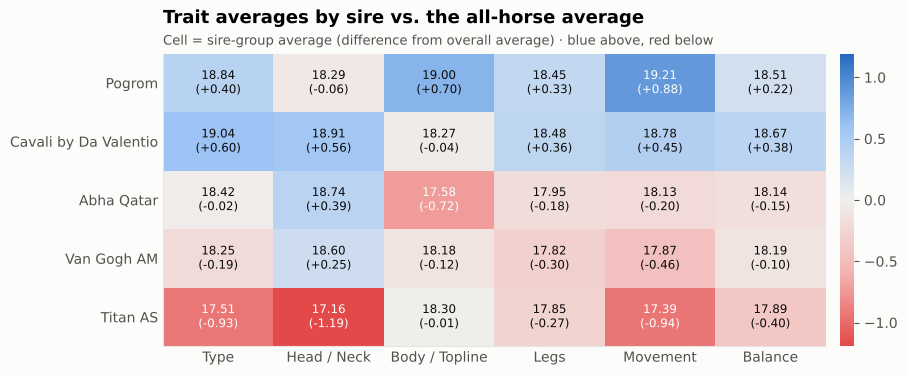

Pogrom                  strongest: Movement        (+0.88)   weakest: Head / Neck     (-0.06)
Cavali by Da Valentio   strongest: Type            (+0.60)   weakest: Body / Topline  (-0.04)
Abha Qatar              strongest: Head / Neck     (+0.39)   weakest: Body / Topline  (-0.72)
Van Gogh AM             strongest: Head / Neck     (+0.25)   weakest: Movement        (-0.46)
Titan AS                strongest: Body / Topline  (-0.01)   weakest: Head / Neck     (-1.19)


In [11]:
trait_sire = hs.groupby('Sire')[TRAITS].mean().loc[sire.index]
trait_dev = trait_sire - hs[TRAITS].mean()
trait_sire.to_csv(TABLES / 'trait_by_sire.csv')

fig, ax = plt.subplots(figsize=(9, 3.8))
lim = np.abs(trait_dev.values).max()
im = ax.imshow(trait_dev.values, cmap=DIV, norm=TwoSlopeNorm(0, -lim, lim), aspect='auto')
for (i, j), v in np.ndenumerate(trait_dev.values):
    ax.text(j, i, f'{trait_sire.values[i, j]:.2f}\n({v:+.2f})', ha='center', va='center', fontsize=8.5,
            color='white' if abs(v) > lim * 0.6 else INK)
ax.set_xticks(range(len(TRAITS)), [TRAIT_LABELS[t] for t in TRAITS])
ax.set_yticks(range(len(trait_sire)), trait_sire.index)
ax.grid(False); ax.tick_params(length=0)
ax.set_title('Trait averages by sire vs. the all-horse average', pad=22)
subtitle(ax, 'Cell = sire-group average (difference from overall average) · blue above, red below')
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02); cb.outline.set_visible(False)
save(fig, '03_trait_heatmap_by_sire')

for s in trait_dev.index:
    r = trait_dev.loc[s]
    print(f'{s:<23} strongest: {TRAIT_LABELS[r.idxmax()]:<15} ({r.max():+.2f})   weakest: {TRAIT_LABELS[r.idxmin()]:<15} ({r.min():+.2f})')

## 6 · Parent performance vs. offspring

In [12]:
r_sire, p_sire = stats.pearsonr(sire.SireShowScore, sire.AvgTotal)
ds = (hs.groupby('DamSire').agg(Horses=('HorseID', 'count'), AvgTotal=('AvgTotal', 'mean'),
                                DamSireScore=('DamSireScore', 'first'), Line=('DamLine', lambda s: s.mode()[0]))
      .sort_values('AvgTotal', ascending=False))
r_ds, p_ds = stats.pearsonr(hs.DamSireScore, hs.AvgTotal)
r_mp, p_mp = stats.pearsonr(hs.MidParentScore, hs.AvgTotal)
slope, intercept, *_ = stats.linregress(hs.MidParentScore, hs.AvgTotal)
ds.to_csv(TABLES / 'damsire_comparison.csv')

print(f'Sire show score vs offspring average (5 sires):       r = {r_sire:+.2f}, p = {p_sire:.2f}')
print(f'Dam-sire show score vs horse score (40 horses):       r = {r_ds:+.2f}, p = {p_ds:.2f}')
print(f'Mid-parent score vs horse score (40 horses):          r = {r_mp:+.2f}, p = {p_mp:.2g}')
print(f'Regression: each +1 pt of mid-parent score -> {slope:+.2f} pts in offspring score')
ds

Sire show score vs offspring average (5 sires):       r = +0.78, p = 0.12
Dam-sire show score vs horse score (40 horses):       r = +0.06, p = 0.70
Mid-parent score vs horse score (40 horses):          r = +0.23, p = 0.15
Regression: each +1 pt of mid-parent score -> +0.58 pts in offspring score


,Horses,AvgTotal,DamSireScore,Line
DamSire,,,,
Bey Shah,4,111.79,111.5,Domestic
Gazal Al Shaqab,6,111.37,107.6,Polish
Marwan Al Shaqab,2,111.05,107.2,Crabbet-influenced
Magnum Psyche,4,110.25,106.5,Crabbet-influenced
Versace,6,109.79,106.3,Egyptian-influenced
El Nabila B,8,109.62,106.5,Crabbet-influenced
Ali Jamaal,4,108.70,109.7,Polish
Padron,4,108.38,112.0,Egyptian-influenced
Da Valentino,1,107.73,106.8,Spanish


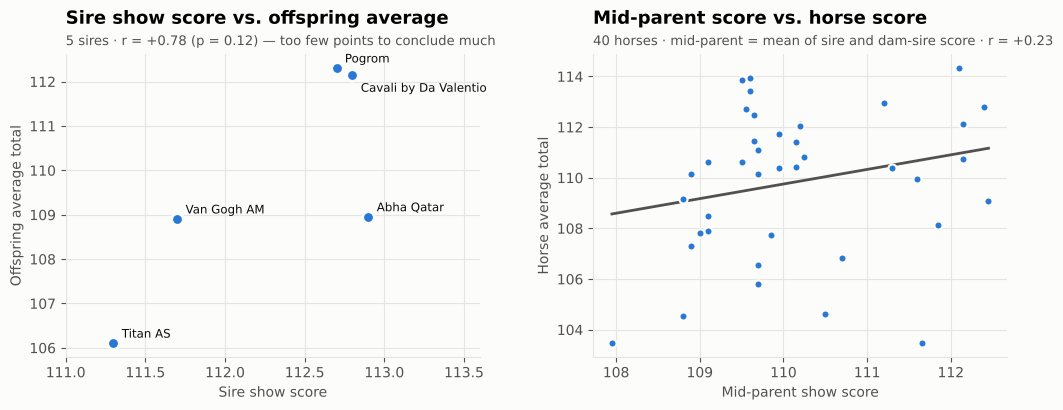

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.scatter(sire.SireShowScore, sire.AvgTotal, s=70, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3)
for s, r in sire.iterrows():
    ax.annotate(s, (r.SireShowScore, r.AvgTotal), xytext=(6, -12 if s.startswith('Cavali') else 4),
                textcoords='offset points', fontsize=8.5, color=INK)
ax.set_title('Sire show score vs. offspring average', pad=22)
subtitle(ax, f'5 sires · r = {r_sire:+.2f} (p = {p_sire:.2f}) — too few points to conclude much')
ax.set_xlabel('Sire show score'); ax.set_ylabel('Offspring average total')
ax.set_xlim(111, 113.6)

ax = axes[1]
ax.scatter(hs.MidParentScore, hs.AvgTotal, s=34, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
xs = np.linspace(hs.MidParentScore.min(), hs.MidParentScore.max(), 50)
ax.plot(xs, intercept + slope * xs, color=INK2, lw=2)
ax.set_title('Mid-parent score vs. horse score', pad=22)
subtitle(ax, f'40 horses · mid-parent = mean of sire and dam-sire score · r = {r_mp:+.2f}')
ax.set_xlabel('Mid-parent show score'); ax.set_ylabel('Horse average total')
fig.tight_layout()
save(fig, '04_parent_vs_offspring')

## 7 · Age group and sex

In [14]:
age_order = ['Junior', 'Young Horse', 'Mature']
sex_order = ['Colt', 'Filly', 'Gelding', 'Mare', 'Stallion']
pv = hs.pivot_table(index='AgeGroup', columns='Sex', values='AvgTotal', aggfunc='mean').reindex(index=age_order, columns=sex_order)
pn = hs.pivot_table(index='AgeGroup', columns='Sex', values='HorseID', aggfunc='count').reindex(index=age_order, columns=sex_order)
age = hs.groupby('AgeGroup').AvgTotal.agg(['count', 'mean', 'std']).reindex(age_order)
sex = hs.groupby('Sex').AvgTotal.agg(['count', 'mean', 'std']).reindex(sex_order)
pv.to_csv(TABLES / 'age_sex_matrix.csv')
print(f"Age group ANOVA p = {stats.f_oneway(*[g.AvgTotal for _, g in hs.groupby('AgeGroup')]).pvalue:.2f}")
print(f"Sex ANOVA p       = {stats.f_oneway(*[g.AvgTotal for _, g in hs.groupby('Sex')]).pvalue:.2f}")
display(age.round(2), sex.round(2))

Age group ANOVA p = 0.05
Sex ANOVA p       = 0.45


,count,mean,std
AgeGroup,,,
Junior,13,108.30,3.17
Young Horse,9,110.21,3.45
Mature,18,110.77,1.93


,count,mean,std
Sex,,,
Colt,9,111.23,2.21
Filly,8,109.92,2.74
Gelding,7,109.05,4.21
Mare,8,108.72,2.93
Stallion,8,110.01,2.27


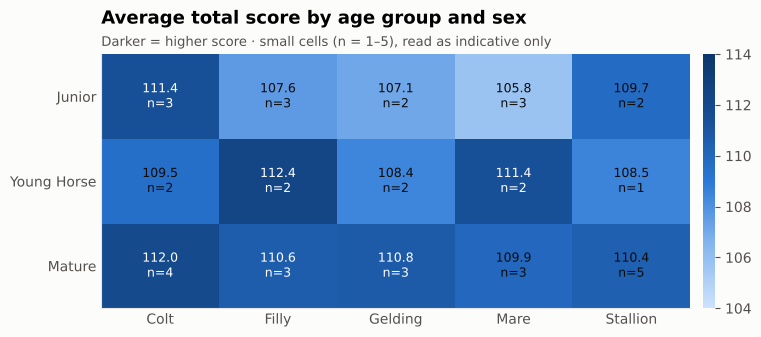

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.3))
im = ax.imshow(pv.values, cmap=SEQ, aspect='auto', vmin=104, vmax=114)
for (i, j), v in np.ndenumerate(pv.values):
    ax.text(j, i, f'{v:.1f}\nn={int(pn.values[i, j])}', ha='center', va='center', fontsize=9,
            color='white' if v > 110.5 else INK)
ax.set_xticks(range(len(sex_order)), sex_order); ax.set_yticks(range(len(age_order)), age_order)
ax.grid(False); ax.tick_params(length=0)
ax.set_title('Average total score by age group and sex', pad=22)
subtitle(ax, 'Darker = higher score · small cells (n = 1–5), read as indicative only')
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02); cb.outline.set_visible(False)
save(fig, '05_age_sex_heatmap')

## 8 · Conformation strengths and weaknesses across the herd

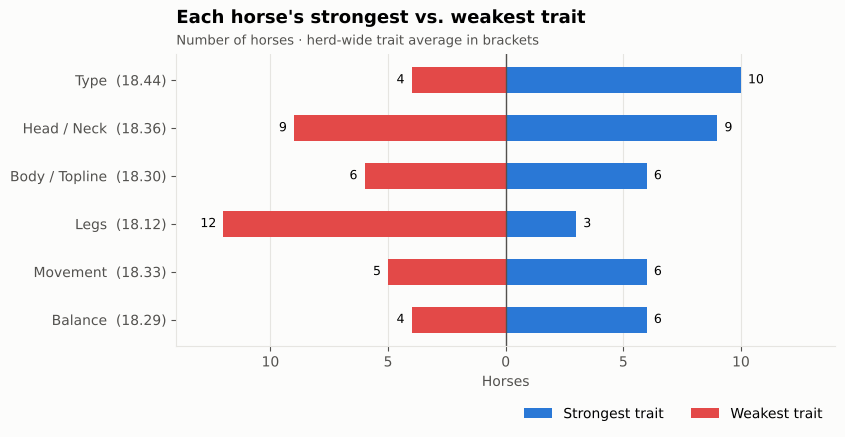

,Average,StrongestFor,WeakestFor
Type,18.44,10,4
Head_Neck,18.36,9,9
Body_Topline,18.30,6,6
Legs,18.12,3,12
Movement,18.33,6,5
Balance,18.29,6,4


In [16]:
trait_all = pd.DataFrame({
    'Average': hs[TRAITS].mean(),
    'StrongestFor': hs.MainStrength.value_counts().reindex(TRAITS, fill_value=0),
    'WeakestFor': hs.FocusArea.value_counts().reindex(TRAITS, fill_value=0)})
trait_all.to_csv(TABLES / 'trait_strength_weakness.csv')

fig, ax = plt.subplots(figsize=(8.5, 3.8))
y = np.arange(len(TRAITS))[::-1]
ax.barh(y, trait_all.StrongestFor, color=BLUE, height=0.55, label='Strongest trait')
ax.barh(y, -trait_all.WeakestFor, color=RED, height=0.55, label='Weakest trait')
for yi, t in zip(y, TRAITS):
    ax.text(trait_all.StrongestFor[t] + 0.3, yi, str(trait_all.StrongestFor[t]), va='center', fontsize=9)
    ax.text(-trait_all.WeakestFor[t] - 0.3, yi, str(trait_all.WeakestFor[t]), va='center', ha='right', fontsize=9)
ax.set_yticks(y, [f"{TRAIT_LABELS[t]}  ({trait_all.Average[t]:.2f})" for t in TRAITS])
ax.axvline(0, color=INK2, lw=1); ax.grid(axis='y', visible=False)
m = trait_all[['StrongestFor', 'WeakestFor']].values.max() + 2
ax.set_xlim(-m, m); ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{abs(v):.0f}'))
ax.set_title("Each horse's strongest vs. weakest trait", pad=22)
subtitle(ax, 'Number of horses · herd-wide trait average in brackets')
ax.legend(loc='lower right', ncol=2, bbox_to_anchor=(1, -0.3))
ax.set_xlabel('Horses')
save(fig, '06_strengths_weaknesses')
trait_all

In [17]:
corr = hs[TRAITS].corr()
corr.to_csv(TABLES / 'trait_correlation.csv')
print('Trait correlations (horse-level averages):')
corr.round(2)

Trait correlations (horse-level averages):


,Type,Head_Neck,Body_Topline,Legs,Movement,Balance
Type,1.00,0.43,0.14,0.39,0.37,0.51
Head_Neck,0.43,1.00,-0.14,0.04,0.43,0.36
Body_Topline,0.14,-0.14,1.00,0.29,0.40,0.02
Legs,0.39,0.04,0.29,1.00,0.24,0.18
Movement,0.37,0.43,0.40,0.24,1.00,0.42
Balance,0.51,0.36,0.02,0.18,0.42,1.00


## 9 · Judge consistency

In [18]:
judge_trait = scores.groupby('Judge')[TRAITS + ['TotalScore']].mean()
judge_dev = judge_trait - scores[TRAITS + ['TotalScore']].mean()
wide = scores.pivot(index='HorseID', columns='Judge', values='TotalScore')
judge_corr = wide.corr()
# ICC(2,1): two-way random, absolute agreement, single rater
n, kj = wide.shape
grand = wide.values.mean()
msr = kj * ((wide.mean(axis=1) - grand)**2).sum() / (n - 1)
msc = n * ((wide.mean(axis=0) - grand)**2).sum() / (kj - 1)
mse = ((wide.values - wide.mean(axis=1).values[:, None] - wide.mean(axis=0).values[None, :] + grand)**2).sum() / ((n - 1) * (kj - 1))
icc = (msr - mse) / (msr + (kj - 1) * mse + kj * (msc - mse) / n)
fr = stats.friedmanchisquare(*[wide[c] for c in wide.columns])
judge_trait.to_csv(TABLES / 'judge_trait_means.csv')

print(f'ICC(2,1) absolute agreement on totals: {icc:.2f}')
print(f'Friedman test (do judges score at different levels?): p = {fr.pvalue:.2g}')
print('\nCorrelation between judges on total score:'); display(judge_corr.round(2))
judge_trait.round(2)

ICC(2,1) absolute agreement on totals: 0.46
Friedman test (do judges score at different levels?): p = 0.017

Correlation between judges on total score:


Judge,Judge A,Judge B,Judge C
Judge,,,
Judge A,1.00,0.56,0.50
Judge B,0.56,1.00,0.46
Judge C,0.50,0.46,1.00


,Type,Head_Neck,Body_Topline,Legs,Movement,Balance,TotalScore
Judge,,,,,,,
Judge A,18.71,18.70,18.29,18.33,18.46,18.39,110.89
Judge B,18.34,18.29,18.46,18.12,18.17,18.26,109.64
Judge C,18.27,18.08,18.15,17.93,18.36,18.22,109.00


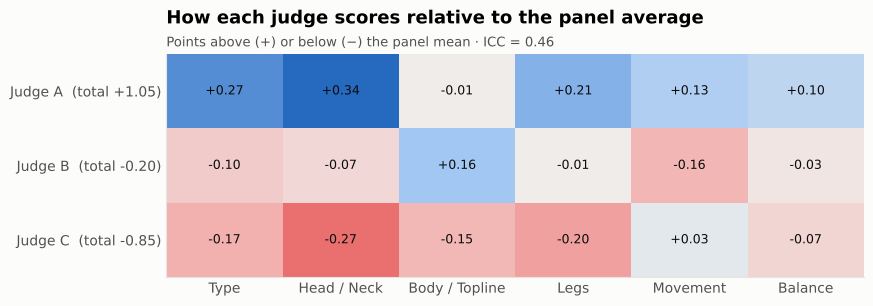

In [19]:
fig, ax = plt.subplots(figsize=(9, 2.9))
cols = TRAITS
vals = judge_dev[cols]
lim = np.abs(vals.values).max()
im = ax.imshow(vals.values, cmap=DIV, norm=TwoSlopeNorm(0, -lim, lim), aspect='auto')
for (i, j), v in np.ndenumerate(judge_dev[cols].values):
    ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=9, color=INK)
ax.set_xticks(range(len(cols)), [TRAIT_LABELS[c] for c in cols])
ax.set_yticks(range(3), [f'{j}  (total {judge_dev.TotalScore[j]:+.2f})' for j in judge_dev.index]); ax.grid(False); ax.tick_params(length=0)
ax.set_title('How each judge scores relative to the panel average', pad=22)
subtitle(ax, f'Points above (+) or below (−) the panel mean · ICC = {icc:.2f}')
save(fig, '07_judge_bias')

## 10 · Top 10 horses

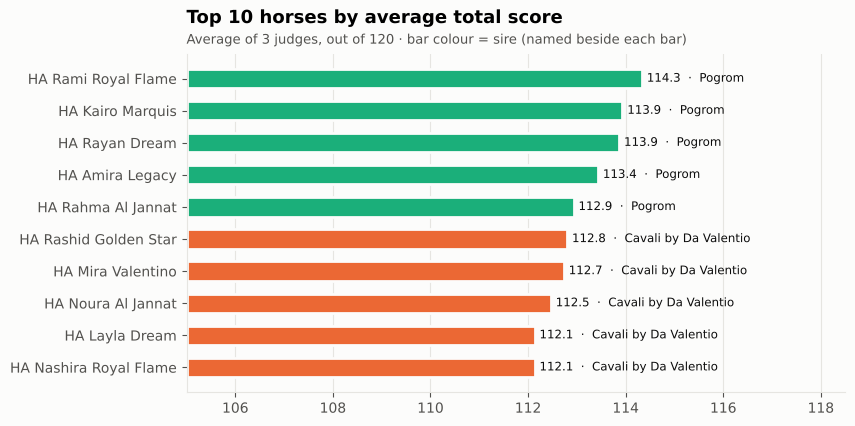

In [20]:
top = hs.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(top.RegisteredName, top.AvgTotal - 105, left=105, color=[SIRE_COLORS[s] for s in top.Sire],
        height=0.6, edgecolor=SURFACE, linewidth=2)
for i, (_, r) in enumerate(top.iterrows()):
    ax.text(r.AvgTotal + 0.1, i, f'{r.AvgTotal:.1f}  ·  {r.Sire}', va='center', fontsize=8.5, color=INK)
ax.set_xlim(105, 118.5); ax.grid(axis='y', visible=False)
ax.set_title('Top 10 horses by average total score', pad=22)
subtitle(ax, 'Average of 3 judges, out of 120 · bar colour = sire (named beside each bar)')
save(fig, '08_top10_horses')

## 11 · Export the star schema for SQL and Power BI

In [21]:
dim_horse = hs[['HorseID', 'RegisteredName', 'BarnName', 'Sex', 'BirthYear', 'Age', 'AgeGroup', 'Color',
                'CountryOfFoaling', 'Sire', 'Dam', 'DamSire', 'PaternalLine', 'DamLine', 'FarmGroup', 'Notes',
                'DataFlag']].sort_values('HorseID')
dim_parent = parents.drop(columns='Notes').rename(columns={'HypotheticalShowScore': 'ParentShowScore'})
dim_judge = pd.DataFrame({'Judge': sorted(scores.Judge.unique())})
dim_trait = pd.DataFrame({'Trait': TRAITS, 'TraitLabel': [TRAIT_LABELS[t] for t in TRAITS],
                          'SortOrder': range(1, 7), 'MaxScore': 20})
fact_scores = scores[['ScoreID', 'HorseID', 'Judge'] + TRAITS + ['TotalScore', 'JudgeComments']]
fact_trait = scores.melt(id_vars=['ScoreID', 'HorseID', 'Judge'], value_vars=TRAITS, var_name='Trait', value_name='Score')
horse_summary = hs[['HorseID', 'AvgTotal', 'Rank', 'ScoreTier', 'MainStrength', 'FocusArea', 'JudgeSpread',
                    'SireScore', 'DamSireScore', 'MidParentScore'] + TRAITS].sort_values('HorseID')

for name, df in {'dim_horse': dim_horse, 'dim_parent': dim_parent, 'dim_judge': dim_judge, 'dim_trait': dim_trait,
                 'fact_judge_scores': fact_scores, 'fact_trait_scores': fact_trait,
                 'horse_score_summary': horse_summary}.items():
    df.round(4).to_csv(PBI / f'{name}.csv', index=False)
    print(f'{name:<22} {len(df):>4} rows')

dim_horse                40 rows
dim_parent               15 rows
dim_judge                 3 rows
dim_trait                 6 rows
fact_judge_scores       120 rows
fact_trait_scores       720 rows
horse_score_summary      40 rows


## 12 · Key findings

The cell below prints the findings from the numbers computed above, so they stay correct if the data changes.

In [22]:
best, worst = sire.index[0], sire.index[-1]
lines = [
    f"1. **Sire line matters.** {best} ({sire.AvgTotal[best]:.1f}) and {sire.index[1]} ({sire.AvgTotal.iloc[1]:.1f}) offspring lead; "
    f"{worst} trails at {sire.AvgTotal[worst]:.1f}. Sire explains {eta2:.0%} of score variation (ANOVA p = {p_anova:.1g}).",
    f"2. **{sire.StdDev.idxmin()} is the most consistent line** (std dev {sire.StdDev.min():.2f}); {sire.StdDev.idxmax()} is the most variable ({sire.StdDev.max():.2f}).",
    f"   Pairwise tests split the sires into two clear tiers: {sire.index[0]} and {sire.index[1]} beat every other sire after Bonferroni correction.",
    f"3. **Parent show scores are a weak predictor at horse level.** Mid-parent vs offspring r = {r_mp:+.2f} (p = {p_mp:.2f}, not significant); "
    f"dam-sire score alone shows almost no link (r = {r_ds:+.2f}). At sire level the trend is stronger (r = {r_sire:+.2f}) but rests on only 5 sires. "
    f"Abha Qatar has the highest sire score yet mid-table offspring ({sire.GapVsSire['Abha Qatar']:+.1f} vs own score).",
    f"4. **Age matters a little, sex barely.** Mature horses average {age.loc['Mature','mean']:.1f} vs Junior {age.loc['Junior','mean']:.1f} (borderline, p ≈ 0.05); sex differences are not significant.",
    f"5. **Herd-wide weakness: {TRAIT_LABELS[trait_all.Average.idxmin()]}** (lowest average, weakest trait for {trait_all.WeakestFor.max()} horses); "
    f"strongest trait overall is {TRAIT_LABELS[trait_all.Average.idxmax()]}.",
    f"6. **Judges only moderately agree.** ICC = {icc:.2f} (pairwise r ≈ 0.5), and they score at different levels (Friedman p = {fr.pvalue:.2g}): "
    f"Judge A runs {judge_dev.TotalScore['Judge A']:+.2f} pts vs panel, Judge C {judge_dev.TotalScore['Judge C']:+.2f}. Averaging three judges matters.",
    f"7. **Data quality:** {len(flags)} of 40 horses have a sex label that conflicts with their age (e.g. 6-year-old 'colts'), so sex-class results should be treated with caution.",
]
from IPython.display import Markdown
Path(TABLES / 'key_findings.md').write_text('\n'.join(lines))
Markdown('\n\n'.join(lines))

1. **Sire line matters.** Pogrom (112.3) and Cavali by Da Valentio (112.1) offspring lead; Titan AS trails at 106.1. Sire explains 64% of score variation (ANOVA p = 2e-07).

2. **Cavali by Da Valentio is the most consistent line** (std dev 0.69); Titan AS is the most variable (2.76).

   Pairwise tests split the sires into two clear tiers: Pogrom and Cavali by Da Valentio beat every other sire after Bonferroni correction.

3. **Parent show scores are a weak predictor at horse level.** Mid-parent vs offspring r = +0.23 (p = 0.15, not significant); dam-sire score alone shows almost no link (r = +0.06). At sire level the trend is stronger (r = +0.78) but rests on only 5 sires. Abha Qatar has the highest sire score yet mid-table offspring (-3.9 vs own score).

4. **Age matters a little, sex barely.** Mature horses average 110.8 vs Junior 108.3 (borderline, p ≈ 0.05); sex differences are not significant.

5. **Herd-wide weakness: Legs** (lowest average, weakest trait for 12 horses); strongest trait overall is Type.

6. **Judges only moderately agree.** ICC = 0.46 (pairwise r ≈ 0.5), and they score at different levels (Friedman p = 0.017): Judge A runs +1.05 pts vs panel, Judge C -0.85. Averaging three judges matters.

7. **Data quality:** 17 of 40 horses have a sex label that conflicts with their age (e.g. 6-year-old 'colts'), so sex-class results should be treated with caution.